In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv('../data/phishing_url_dataset_raw.csv')
df.shape

(235795, 55)

In [4]:
# Check which columns are non-numeric (text/object type)
df.dtypes[df.dtypes == 'object']

Series([], dtype: object)

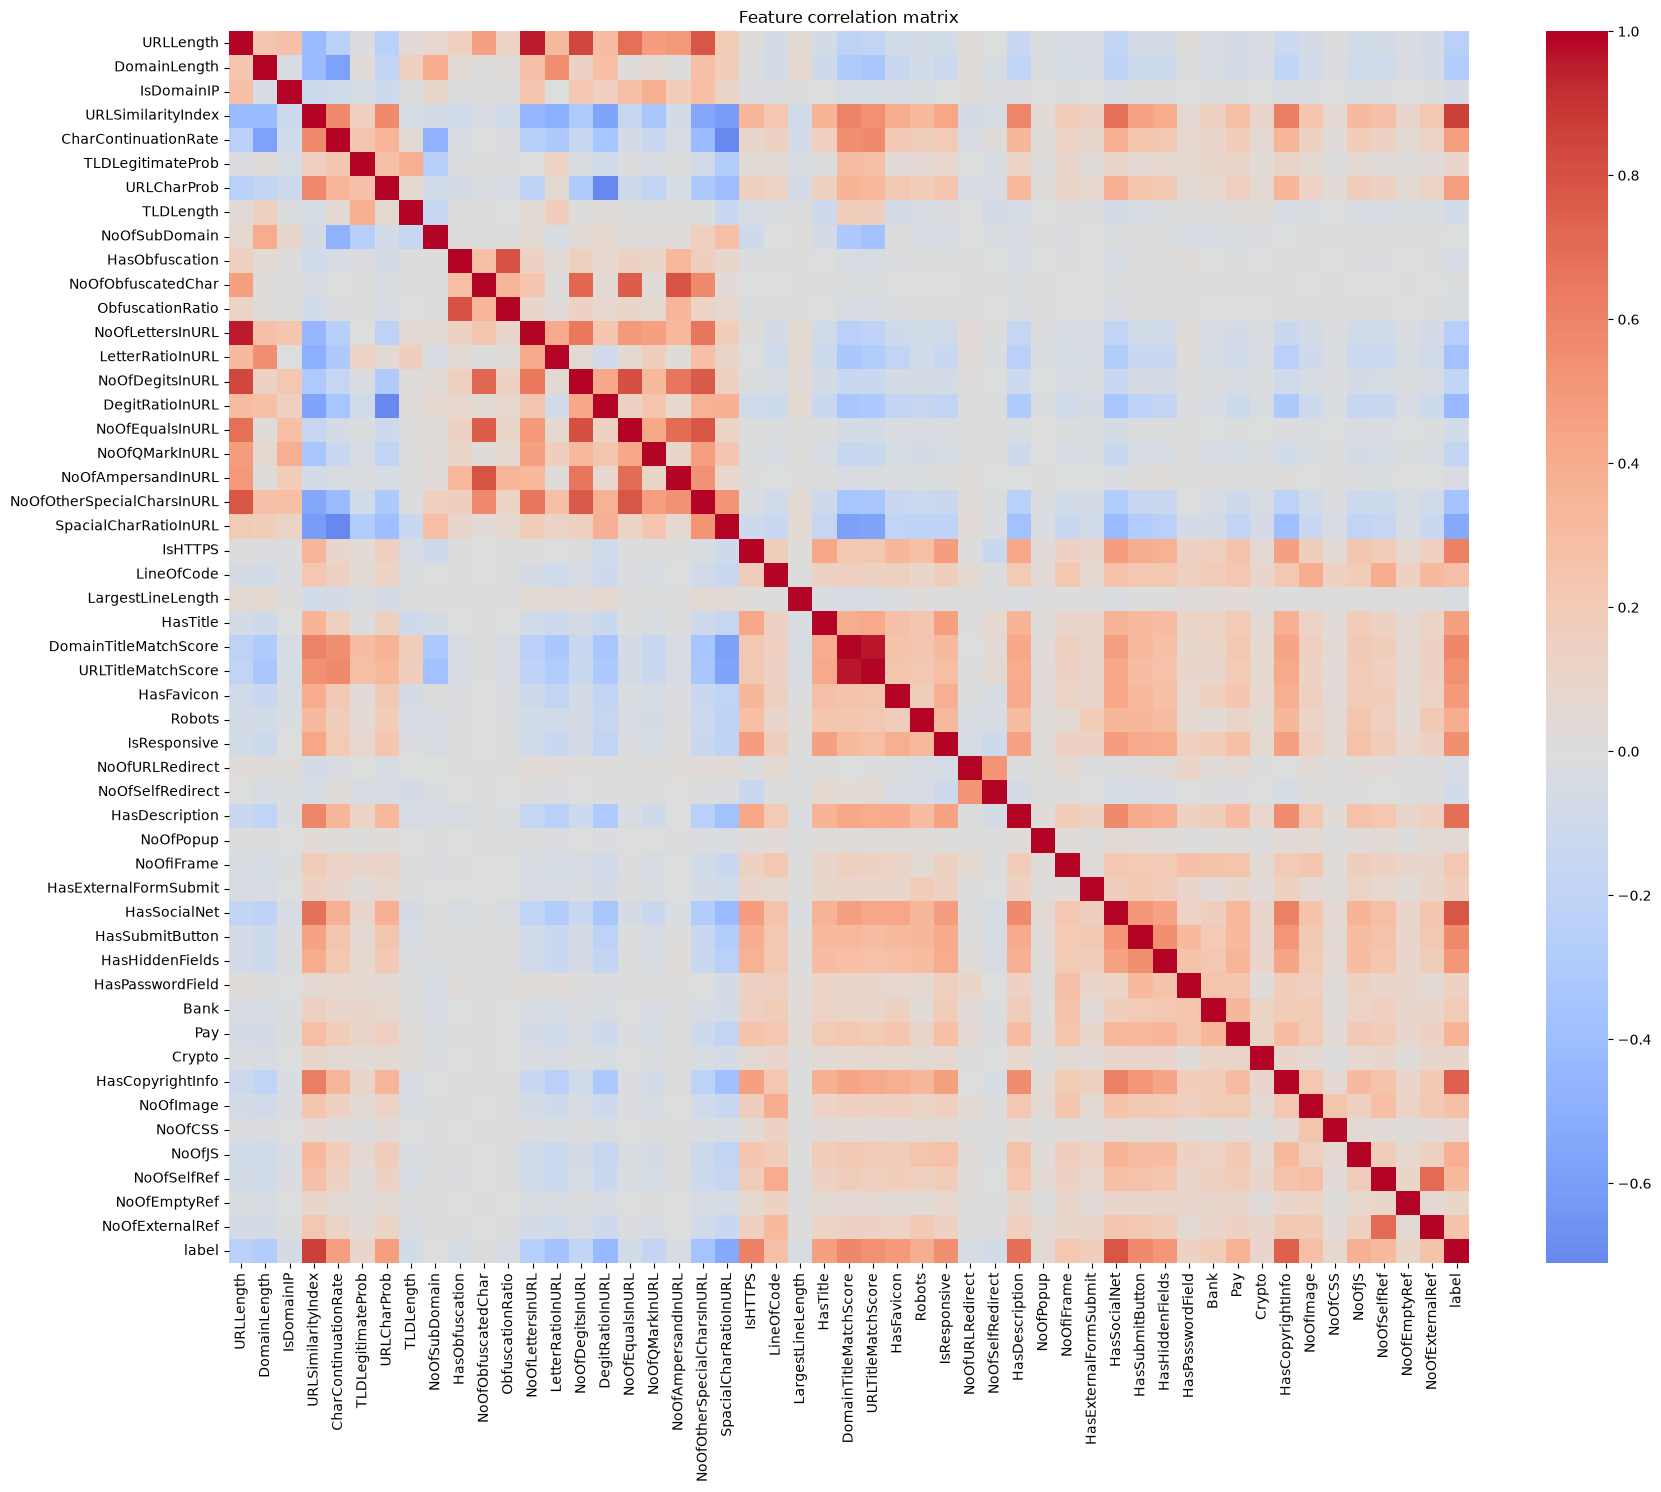

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_numeric.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature correlation matrix')
plt.show()

In [15]:
# Check correlation pairs
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]
corr_pairs.head(20)

DomainTitleMatchScore       URLTitleMatchScore            0.961008
URLTitleMatchScore          DomainTitleMatchScore         0.961008
URLLength                   NoOfLettersInURL              0.956047
NoOfLettersInURL            URLLength                     0.956047
label                       URLSimilarityIndex            0.860358
URLSimilarityIndex          label                         0.860358
NoOfDegitsInURL             URLLength                     0.835809
URLLength                   NoOfDegitsInURL               0.835809
NoOfEqualsInURL             NoOfDegitsInURL               0.806024
NoOfDegitsInURL             NoOfEqualsInURL               0.806024
ObfuscationRatio            HasObfuscation                0.798791
HasObfuscation              ObfuscationRatio              0.798791
NoOfAmpersandInURL          NoOfObfuscatedChar            0.786451
NoOfObfuscatedChar          NoOfAmpersandInURL            0.786451
NoOfEqualsInURL             NoOfOtherSpecialCharsInURL    0.78

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

X = df_numeric.drop('label', axis=1)
y = df_numeric['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(20)

URLSimilarityIndex            0.173672
NoOfExternalRef               0.169276
LineOfCode                    0.153836
NoOfSelfRef                   0.106813
NoOfImage                     0.093526
NoOfJS                        0.069344
HasSocialNet                  0.033428
NoOfCSS                       0.030517
HasCopyrightInfo              0.024518
IsHTTPS                       0.021136
LargestLineLength             0.019596
HasDescription                0.018959
NoOfDegitsInURL               0.012893
NoOfOtherSpecialCharsInURL    0.010878
NoOfLettersInURL              0.010361
DegitRatioInURL               0.008641
DomainTitleMatchScore         0.006942
IsResponsive                  0.006107
URLLength                     0.005143
LetterRatioInURL              0.004229
dtype: float64